<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/5.0%20Churn_Model_Selection%20and%20Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
#!pip install boto3 s3fs

### 1.0 INTRODUCTION
This notebook is aimed at training and validating a churn model, which is designed to use a customer first 60-days tenure, to predict whether they will spend in the next 100-days after the said obsersation. This will allow for intervention for at risk customers.

One the churn model is production ready, it will be uploaded to AWS S3 as a joblib, to ensure it has a centralised access, particularly for production.

In [33]:
import boto3
import sys
import os
import importlib
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

from datetime import datetime

bucket_name = 'sales-data-analytics-portfolio-2026'

os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_ACCESS_KEY_ID"] = userdata.get("AWS_ACCESS_KEY_ID")
os.environ["AWS_DEFAULT_REGION"] = "eu-north-1"

parquet_url = "s3://sales-data-analytics-portfolio-2026/parquet_files/fact_online_retail_clean.parquet"

cutoff_date = '2011-08-31'

df = pd.read_parquet(parquet_url)


df = df[df["InvoiceDate"].dt.date.astype('str') <= cutoff_date]
df.info()
print("\nPreview of data exported from AWS S3 datalake")
print()
df.sort_values("InvoiceDate").head()

<class 'pandas.core.frame.DataFrame'>
Index: 225578 entries, 0 to 225577
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    225578 non-null  object        
 1   StockCode    225578 non-null  object        
 2   Description  225578 non-null  object        
 3   Quantity     225578 non-null  int64         
 4   InvoiceDate  225578 non-null  datetime64[ns]
 5   UnitPrice    225578 non-null  float64       
 6   CustomerID   225578 non-null  float64       
 7   Country      225578 non-null  object        
 8   Revenue      225578 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 17.2+ MB

Preview of data exported from AWS S3 datalake



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### 2.0 FEATURE ENGINEERING
The data imported from S3 was apssed to this projects `feature_engineering` function, and features were extracted from above data. Moreover, the customer segmentation parquet file was streamed from s3, and loaded into a dataframe, and later merged to the features dataframe.

Before commencing with training, churn was defined as `no purchase in 100 days after the 60-day observation window`. The churn labels were computed, and added as a column to the features dataframe. Thereafter, the data was filter, retaining only clients that had a `tenure of 160 days`, this was to esnure that each client had a chance to shop within 60 days from first purchase, and within within 100 after the observation period.

In [34]:
import s3fs

fs = s3fs.S3FileSystem()
function_url = "s3://sales-data-analytics-portfolio-2026/functions/feature_engineering.py"

with fs.open(function_url, "r") as file:
    exec(file.read())


from datetime import timedelta
data = df.groupby("CustomerID").agg(
FirstPurchase = ("InvoiceDate", "min")
).reset_index()

cutoff_days = timedelta(days = 60 )
test_end_days = timedelta(days = 100)

data["Cutoff"] = data["FirstPurchase"] + cutoff_days
data["TestEnd"] = data["Cutoff"] + test_end_days


df = df.merge(data, on = "CustomerID", how = "left")

#Excluding Revenue extreme values

df = df[df["Revenue"]  < df["Revenue"].quantile(0.98)]

X_features = df[df["InvoiceDate"] <= df["Cutoff"]].copy()

# getting last purchase with first window to compute date to churn by customer
lastpurchase = X_features.groupby(["CustomerID"]).agg(LastPurchase = ("InvoiceDate", "max")).reset_index()

df = df.merge(lastpurchase, on = "CustomerID", how = 'left')

# target is pulled from their last purchase within the first 30days/cutoff, up to 100 days or test end period from that date
y_feature = df[(df["InvoiceDate"] > df["LastPurchase"]) & (df["InvoiceDate"] <= (df["LastPurchase"] + test_end_days))].copy()

X_features.drop(["FirstPurchase", "Cutoff", "TestEnd"], axis = 1, inplace = True)
y_feature.drop(["FirstPurchase", "Cutoff", "TestEnd"], axis = 1, inplace = True)


X_features = feature_engineering(X_features)
cust_ids = feature_engineering(y_feature)["CustomerID"].unique()

X_features["Churned"] = np.where(X_features["CustomerID"].isin(cust_ids), 0, 1)

after_cutoff = pd.DataFrame(X_features["CustomerID"]).merge(y_feature, how = 'left', on = "CustomerID")

features = X_features.fillna(0)

parquet_url = "s3://sales-data-analytics-portfolio-2026/parquet_files/segmented_features.parquet"
segmented_df = pd.read_parquet(parquet_url)

features = features.merge(segmented_df, on = "CustomerID", how = "inner")

#Ensuring each client has at least a 160 days tenure
features = features.query('Tenure >= 160')

print("Preview of computed features and target")
features.info()
features.head()

Preview of computed features and target
<class 'pandas.core.frame.DataFrame'>
Index: 2007 entries, 0 to 3235
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype    
---  ------                   --------------  -----    
 0   CustomerID               2007 non-null   float64  
 1   Frequency                2007 non-null   int64    
 2   ProductDiversity         2007 non-null   int64    
 3   AvgUnitPrice             2007 non-null   float64  
 4   AvgQuantity              2007 non-null   float64  
 5   AOV                      2007 non-null   float64  
 6   TotalRevenue             2007 non-null   float64  
 7   CohortMonth              2007 non-null   period[M]
 8   Recency                  2007 non-null   int64    
 9   Tenure                   2007 non-null   int64    
 10  ObservedLifeSpan         2007 non-null   int64    
 11  RecencyToTenure          2007 non-null   float64  
 12  ActivePurchaseDensity    2007 non-null   float64  
 13  LifetimePurch

,CustomerID,Frequency,ProductDiversity,AvgUnitPrice,AvgQuantity,AOV,TotalRevenue,CohortMonth,Recency,Tenure,...,RecencyToTenure,ActivePurchaseDensity,LifetimePurchaseDensity,ActiveMRate,LifetimeMRate,AvgIPI,RelativeSilence,Churned,KSegment,Persona
0,12347.0,2,49,2.712667,10.566667,19.786333,1187.18,2010-12,218,268,...,0.813433,0.040000,0.007463,23.743600,4.429776,25.5,8.549020,0,1,Loyal Performer
1,12348.0,2,17,0.552857,88.000000,40.011429,840.24,2010-12,219,258,...,0.848837,0.050000,0.007752,21.006000,3.256744,20.5,10.682927,0,3,One-Time Bulk-Buyer
2,12350.0,1,16,1.581250,12.250000,18.400000,294.40,2011-02,211,211,...,1.000000,1.000000,0.004739,294.400000,1.395261,1.0,211.000000,1,0,One-Time Acquaintance
3,12352.0,4,24,3.720606,7.545455,19.439697,641.51,2011-02,163,197,...,0.827411,0.114286,0.020305,18.328857,3.256396,9.5,17.157895,1,1,Loyal Performer
7,12356.0,1,34,2.506765,34.764706,52.130000,1772.42,2011-01,226,226,...,1.000000,1.000000,0.004425,1772.420000,7.842566,1.0,226.000000,0,3,One-Time Bulk-Buyer


#### 2.1 Feature Selection
All clients at the end of the 60 day mark would have had a tenure of 60 days, and `ObservedLifeSpan`; because the time frameframe is fixed would pick up on recency. That said, the `Tenure`, and `Recency` features were dropped, including all other features relating to the same. `Total Revenue` was dropped, as the model was heavily dependent on revenue to predict churn. Descriptions of the trained `X variables`:

- `Frequency`: Number days a customer showed up
- `ProductDiversity`: Number of unique products purchased
- `AvgUnitPrice`: Average price per unit of items purchased
- `AvgQuantity`: Average quantity purchased on each day
- `AOV`: Daily average order value
- `ObservedLifeSpan`: Number of days between first and last purchase during observation
- `ActivePurchaseDensity`: Total Frequency divided by ObservedLifeSpan
- `ActiveMRate`: TotalRevenue divided by ObservedLifeSpan
- `AvgIPI`: Average Inter-Purchase Interval; average number of days between purchases
- `Persona`: Assigned 60- days, customer segmentation classes, dummy variables.

In [35]:
X = features.drop(["TotalRevenue","Churned", "KSegment","CustomerID", "CohortMonth", "Recency", "Tenure", "RecencyToTenure", "LifetimePurchaseDensity","LifetimeMRate","RelativeSilence"], axis = 1)
X = pd.get_dummies(X, drop_first = True)

X.info()
print("\nPreview of features:")
X.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2007 entries, 0 to 3235
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Frequency                      2007 non-null   int64  
 1   ProductDiversity               2007 non-null   int64  
 2   AvgUnitPrice                   2007 non-null   float64
 3   AvgQuantity                    2007 non-null   float64
 4   AOV                            2007 non-null   float64
 5   ObservedLifeSpan               2007 non-null   int64  
 6   ActivePurchaseDensity          2007 non-null   float64
 7   ActiveMRate                    2007 non-null   float64
 8   AvgIPI                         2007 non-null   float64
 9   Persona_Loyal Performer        2007 non-null   bool   
 10  Persona_One-Time Acquaintance  2007 non-null   bool   
 11  Persona_One-Time Bulk-Buyer    2007 non-null   bool   
dtypes: bool(3), float64(6), int64(3)
memory usage: 162.7 

,Frequency,ProductDiversity,AvgUnitPrice,AvgQuantity,AOV,ObservedLifeSpan,ActivePurchaseDensity,ActiveMRate,AvgIPI,Persona_Loyal Performer,Persona_One-Time Acquaintance,Persona_One-Time Bulk-Buyer
0,2,49,2.712667,10.566667,19.786333,50,0.040000,23.743600,25.5,True,False,False
1,2,17,0.552857,88.000000,40.011429,40,0.050000,21.006000,20.5,False,False,True
2,1,16,1.581250,12.250000,18.400000,1,1.000000,294.400000,1.0,False,True,False
3,4,24,3.720606,7.545455,19.439697,35,0.114286,18.328857,9.5,True,False,False
7,1,34,2.506765,34.764706,52.130000,1,1.000000,1772.420000,1.0,False,False,True


### 3.0 MODEL EVALUATION AND SELECTION

A 5-split KFold cross_validation was conducted on 5 machine learning models, as presented below:

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import ComplementNB

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline



y = features['Churned']

customer_ids = features['CustomerID']

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(X, y, customer_ids, test_size=0.2, random_state = 42, stratify = y)

scaler = StandardScaler()

models = [("Logistic Regression", LogisticRegression(max_iter = 100, class_weight = 'balanced')),
          ("Random Forest", RandomForestClassifier(random_state = 42, class_weight = 'balanced')),
          ("Decision Tree", DecisionTreeClassifier(random_state = 42, class_weight = 'balanced')),
          ("Xgboost", XGBClassifier(random_state = 42)),
          ("Lightgbm", LGBMClassifier(random_state = 42, class_weight = 'balanced', verbose = -1)),
         ]

model_name = []
accuracy_avg = []
precision_avg = []
recall_avg = []
for name, model in models:
  pipeline = make_pipeline(scaler,model)
  kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
  accuracy_scores = cross_val_score(pipeline, X_train, y_train, cv = kf, scoring = 'accuracy')
  precision_scores = cross_val_score(model, X_train, y_train, cv = kf, scoring = 'precision')
  recall_scores = cross_val_score(model, X_train, y_train, cv = kf, scoring = 'recall')

  model_name.append(name)
  accuracy_avg.append(accuracy_scores)
  precision_avg.append(precision_scores)
  recall_avg.append(recall_scores)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

#### 3.1 Evaluating Cross-Validation Classification Metrics by Model

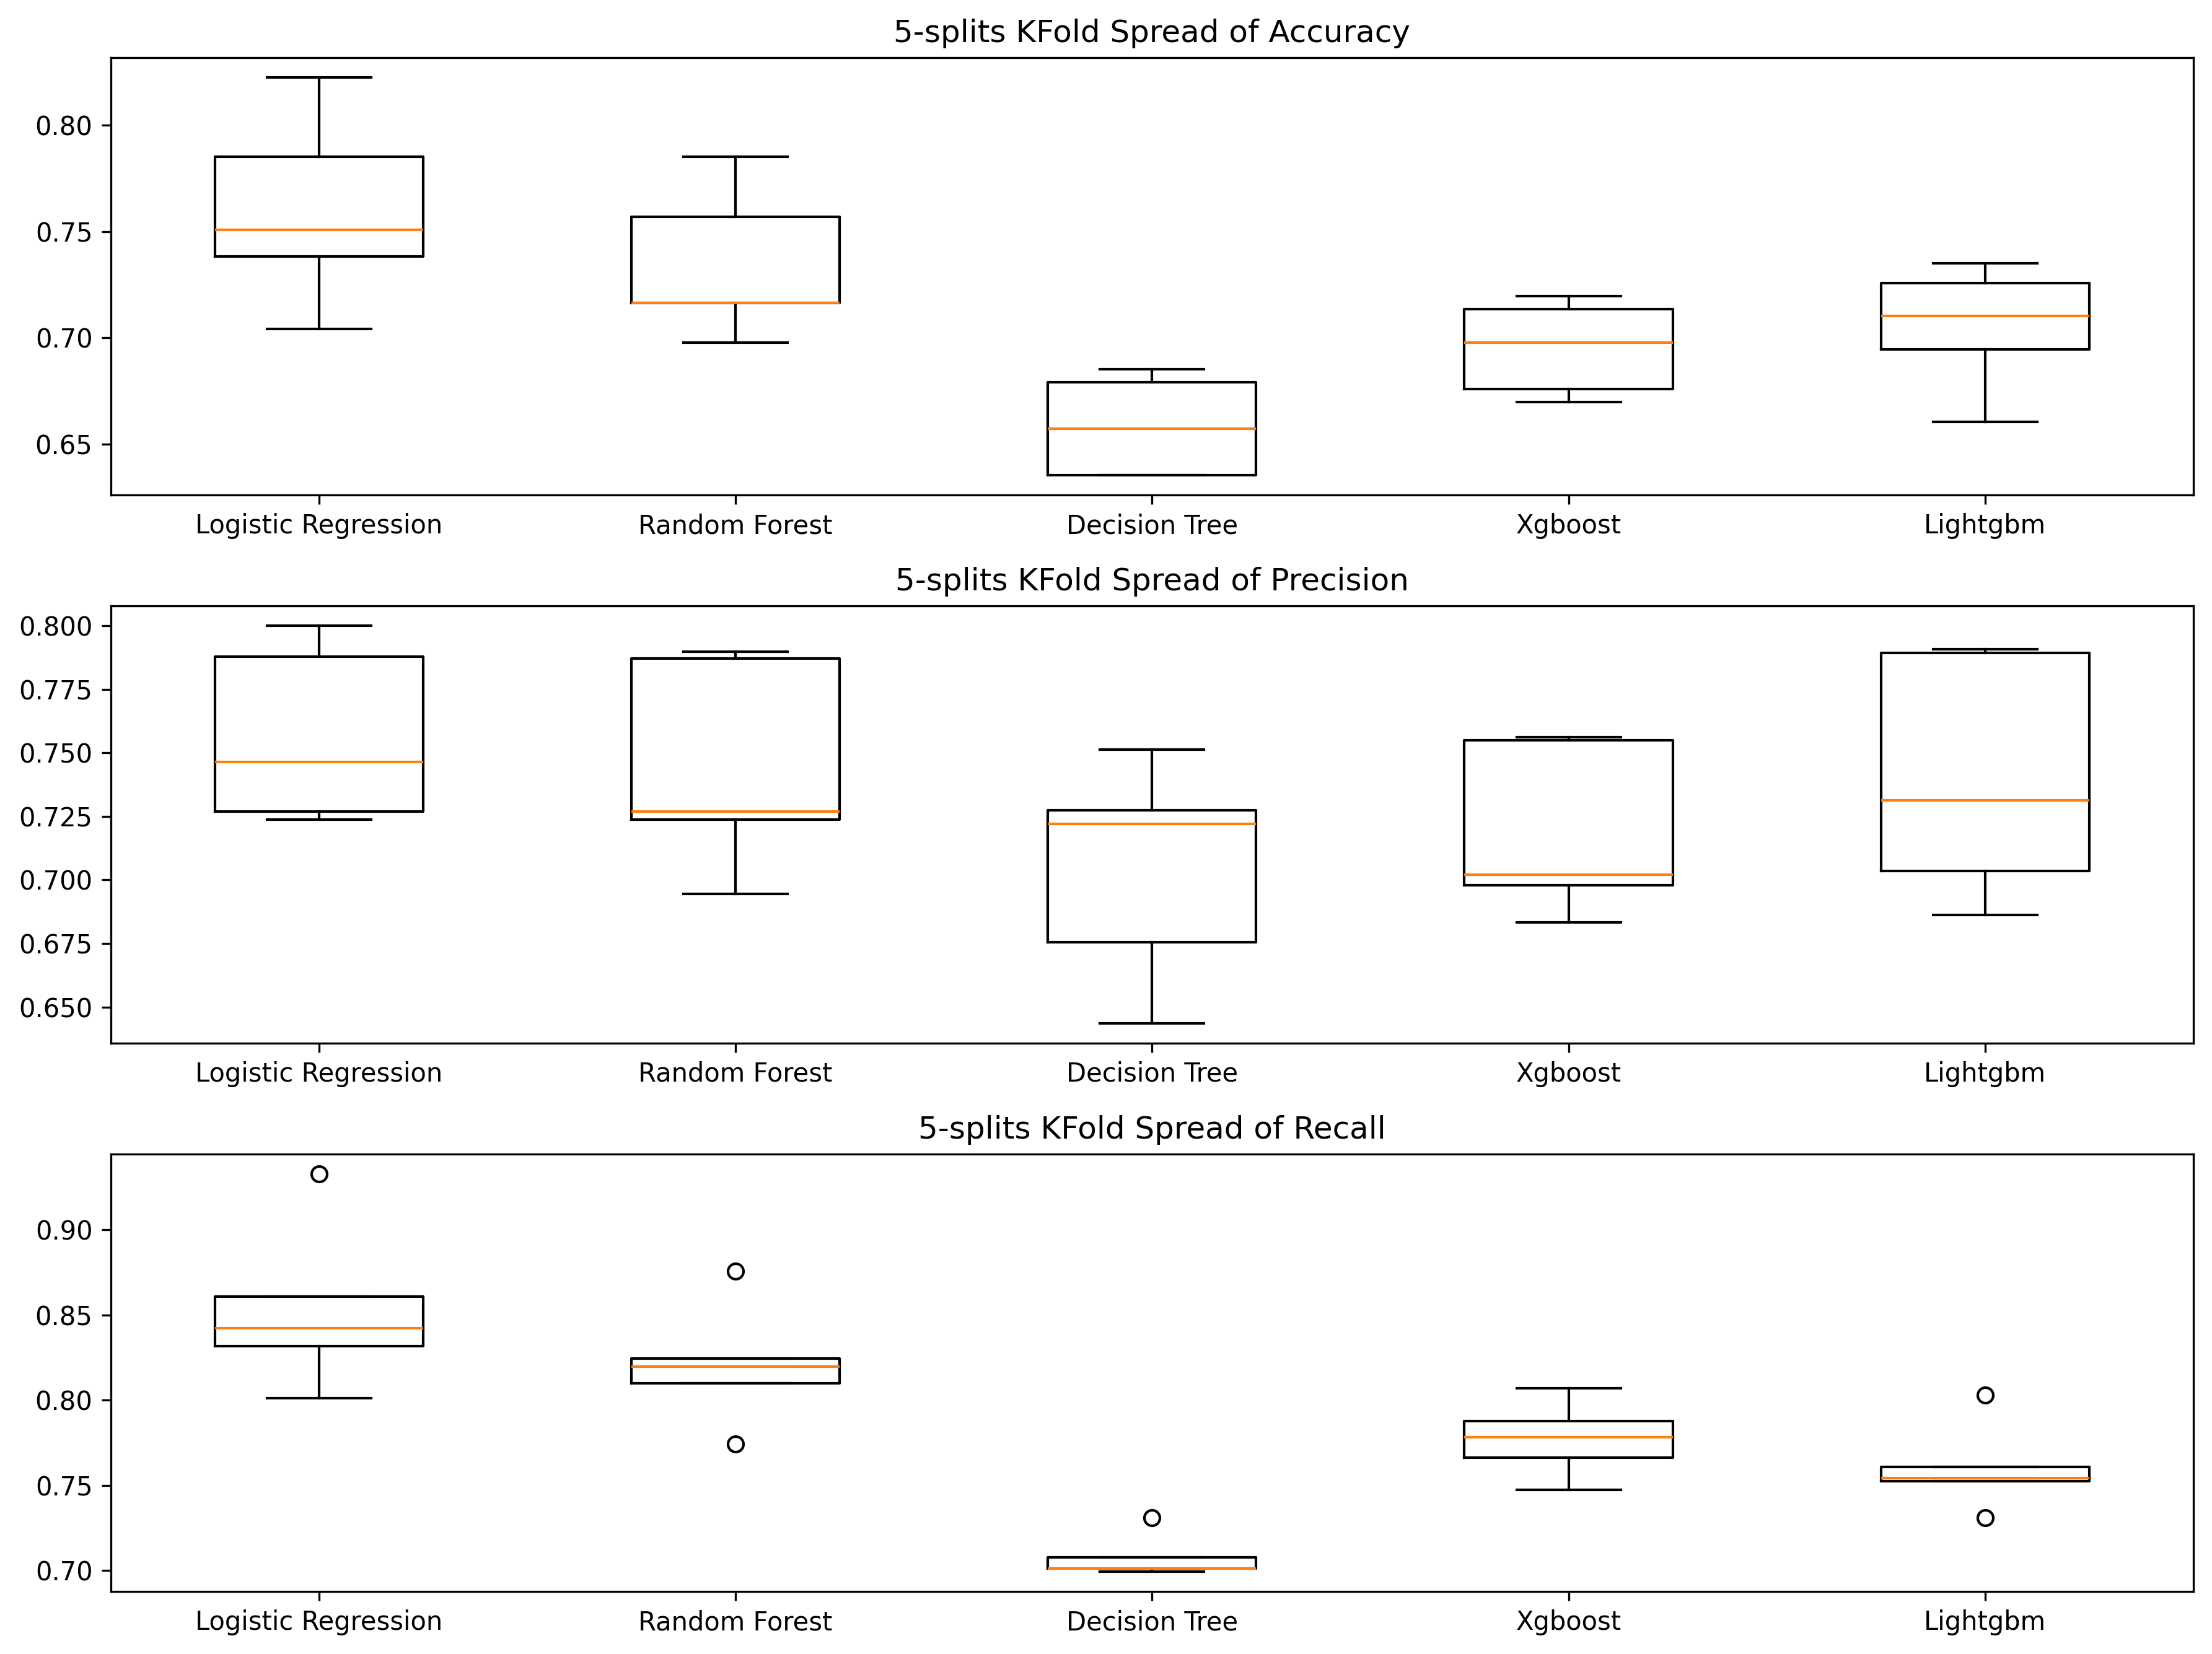

In [37]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize = (12,9), dpi = 300)
ax1.boxplot(accuracy_avg, tick_labels = model_name)
ax1.set_title("5-splits KFold Spread of Accuracy")
ax2.boxplot(precision_avg, tick_labels = model_name)
ax2.set_title("5-splits KFold Spread of Precision")
ax3.boxplot(recall_avg, tick_labels = model_name)
ax3.set_title("5-splits KFold Spread of Recall")
plt.tight_layout()
plt.show()

`Logistic Regression` outperformed the other models, registering the highest `recall`, `precision`, and `accuracy`.

#### 3.2 Out of Sample, Model Validation of Selected Logistic Regression Model

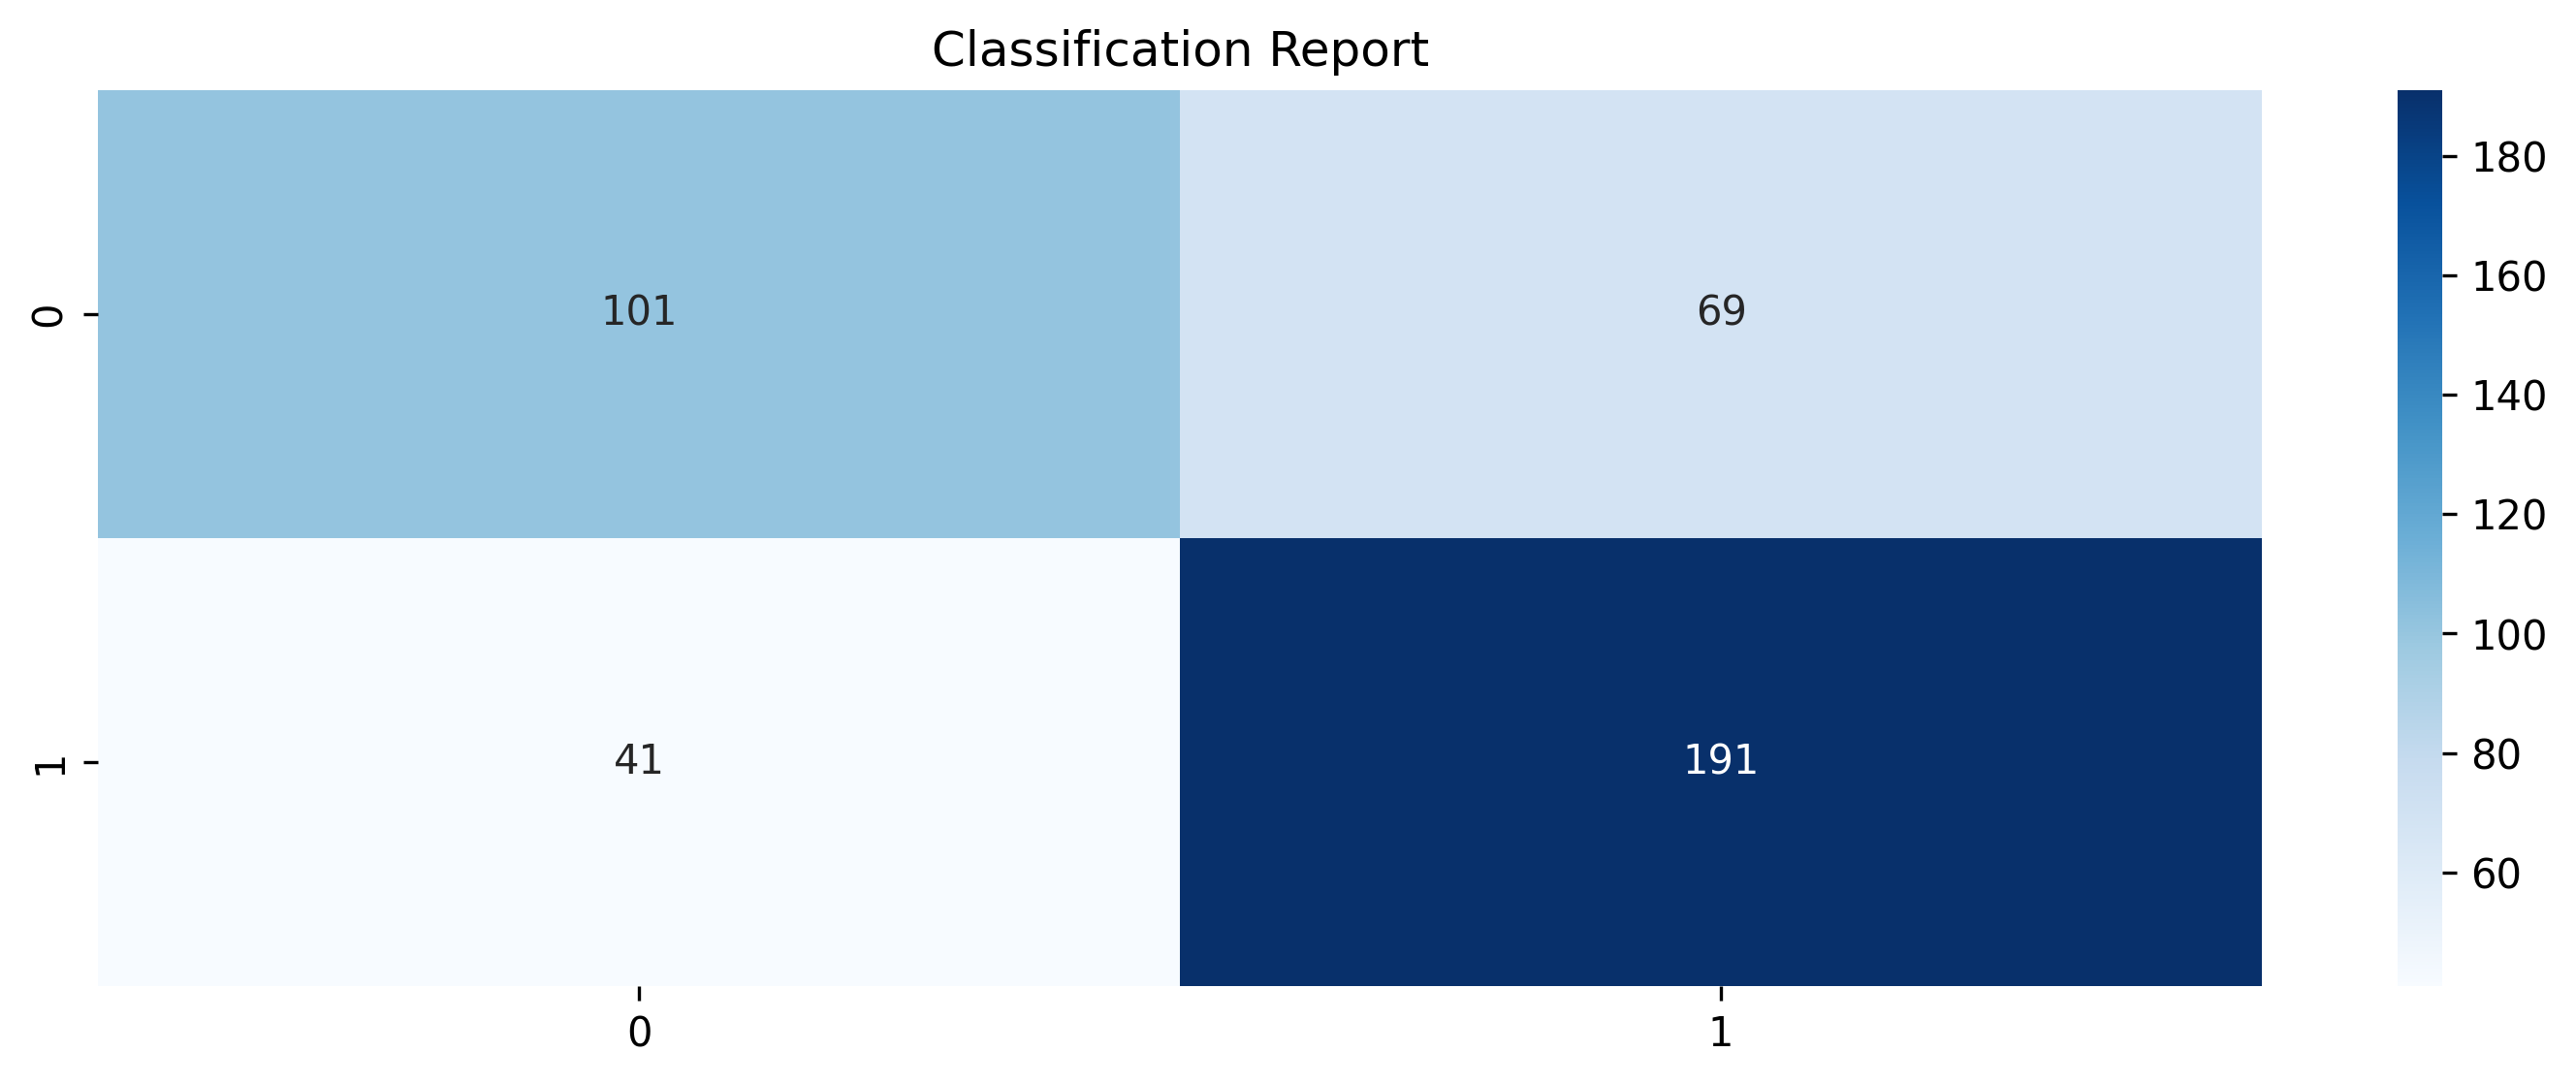

              precision    recall  f1-score   support

           0       0.71      0.59      0.65       170
           1       0.73      0.82      0.78       232

    accuracy                           0.73       402
   macro avg       0.72      0.71      0.71       402
weighted avg       0.72      0.73      0.72       402



In [38]:
import joblib
import s3fs

model = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
#model = RandomForestClassifier(n_estimators = 250, max_depth = 20, min_samples_leaf = 2, random_state = 42, class_weight = 'balanced')
pipeline = make_pipeline(scaler, model)
pipeline.fit(X_train, y_train)

fs = s3fs.S3FileSystem()
model_path = "s3://sales-data-analytics-portfolio-2026/predictive_models/churn_model.joblib"

with fs.open(model_path, "wb") as f:
    joblib.dump(pipeline, f)

with fs.open(model_path, "rb") as f:
    loaded_model = joblib.load(f)

y_pred = loaded_model.predict(X_test)
y_proba = loaded_model.predict_proba(X_test)[:,1]

y_pred = (y_proba > 0.40).astype("int")
c_matrix = confusion_matrix(y_test, y_pred)

# Creating predictions table in Database
pred_df = pd.DataFrame({
    "CustomerID" : ids_test,
    "ActualChurn": y_test,
    "PredictedProbability": y_proba,
    "PredictedLabel": y_pred
})


plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(c_matrix, cmap='Blues', annot = True, fmt = 'g')
plt.title("Classification Report")
plt.show()

print(classification_report(y_test, y_pred))

Recording a `recall` of 0.82, suggests the model catches `82%` of all clients that churn with the first 60days, with an accuracy of `74%` as presented above, catching 191 churners out of 232, missing only 41, and wrongly classifying 69.

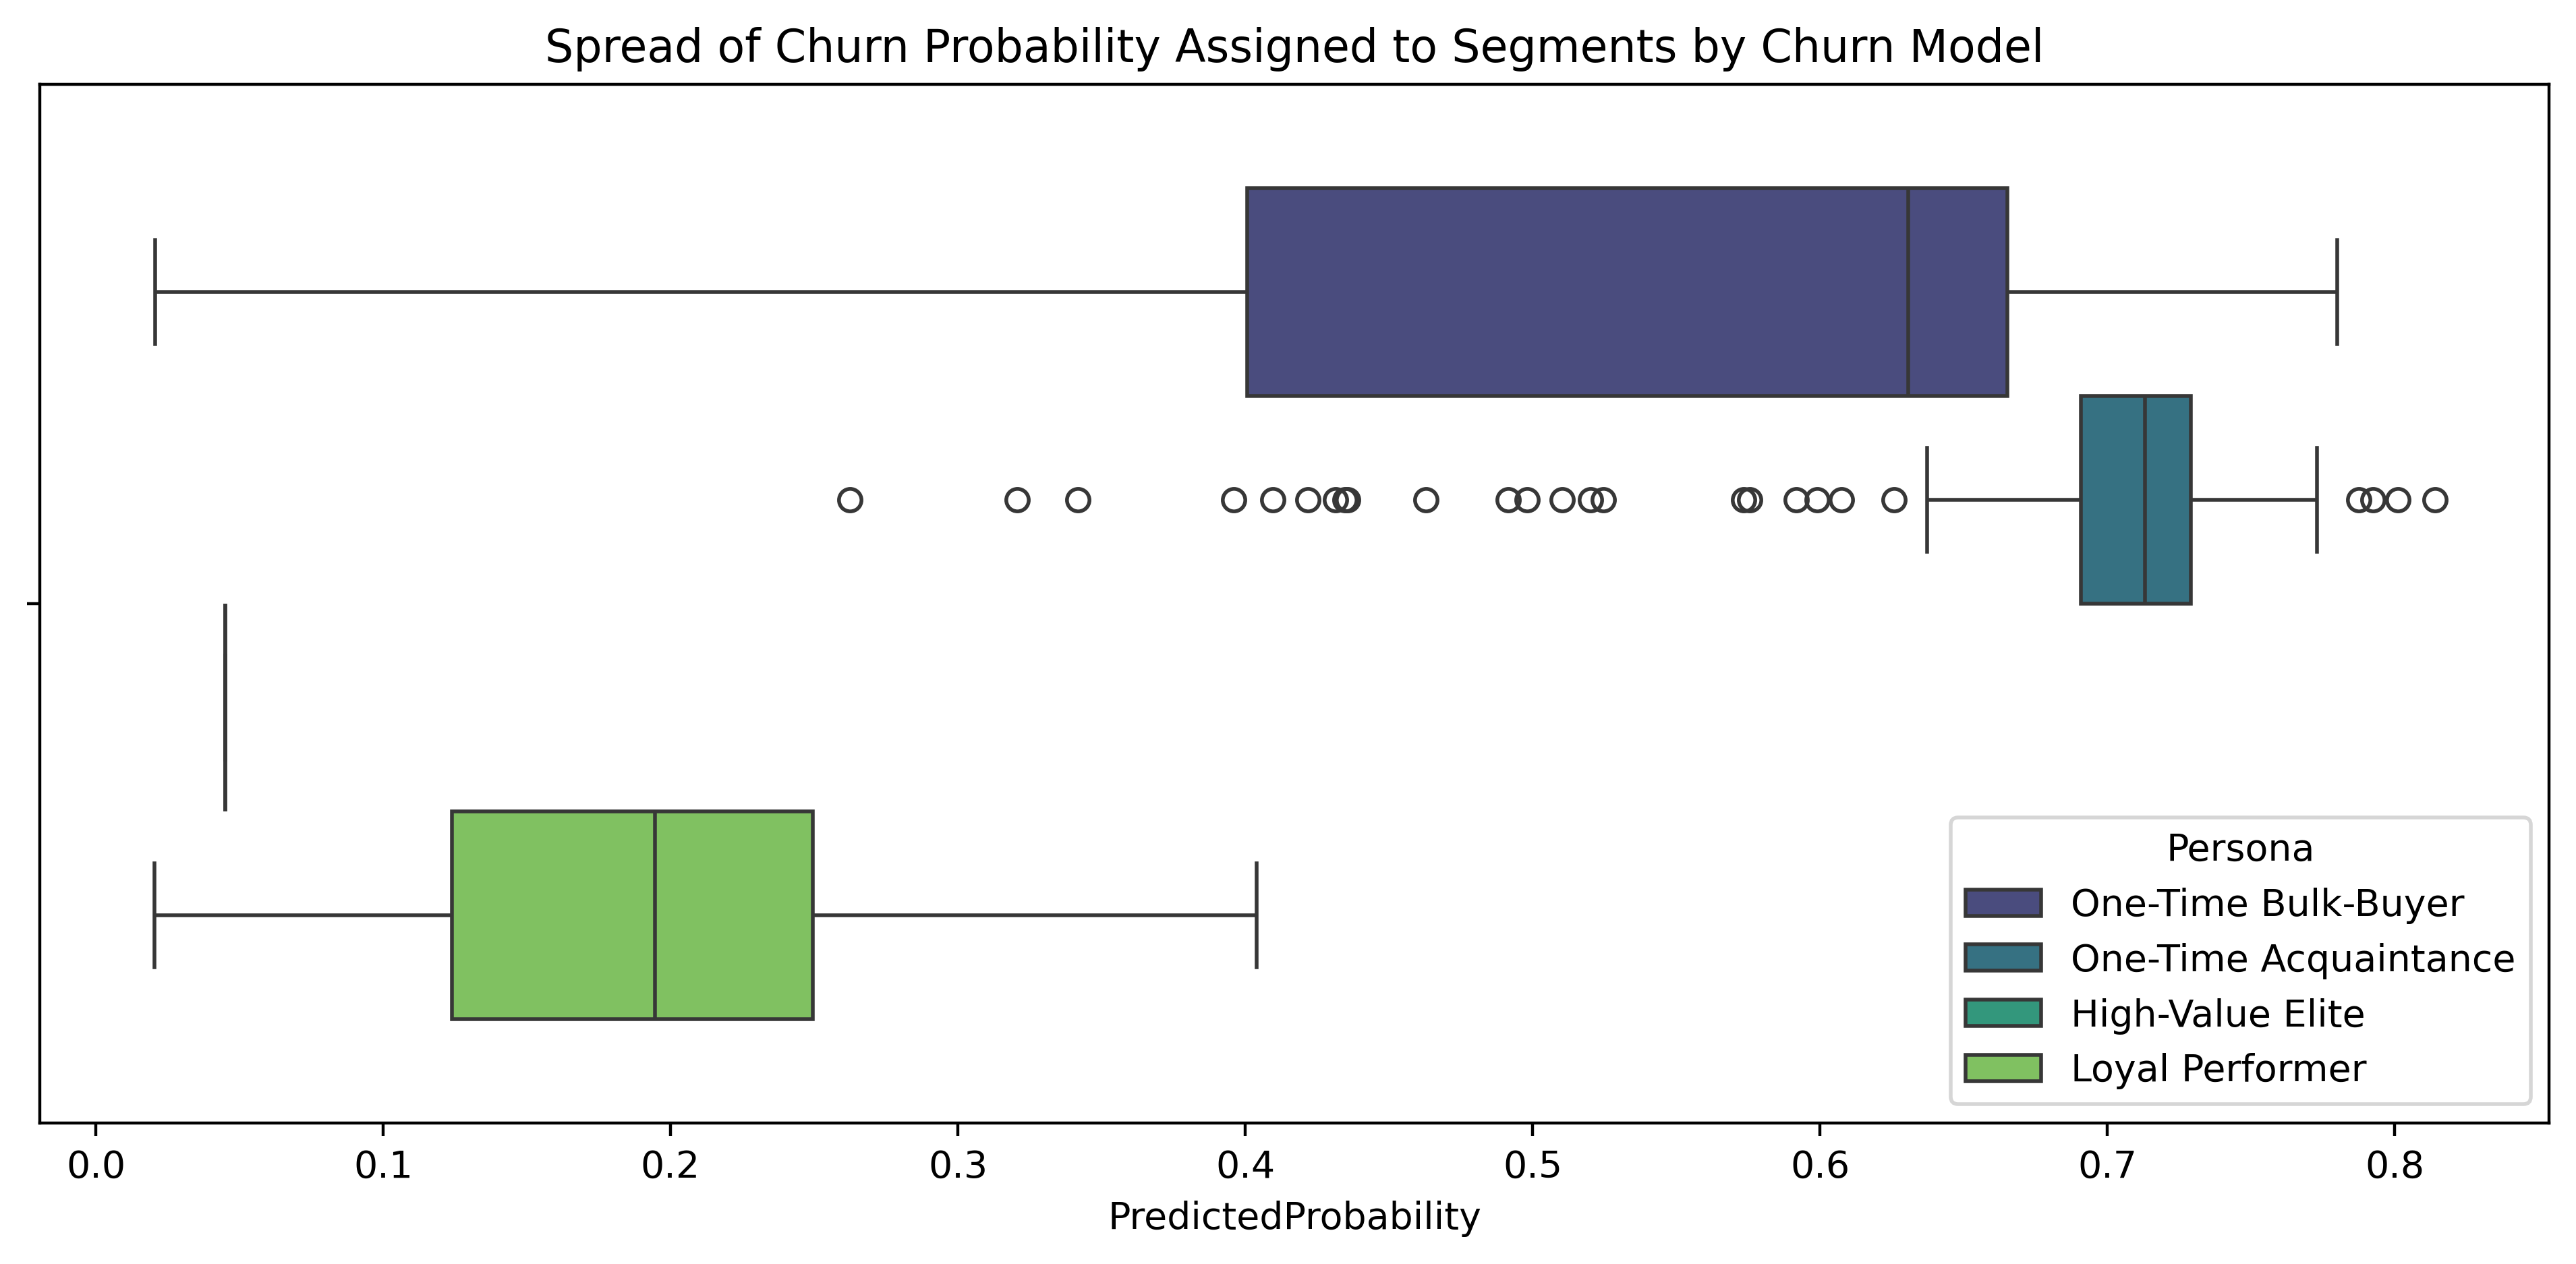

In [39]:
data = pred_df.merge(features, on = "CustomerID", how = "left")
data.head()

plt.figure(figsize =(12,5), dpi = 400)
sns.boxplot(data = data, x = "PredictedProbability", hue = "Persona", palette = 'viridis')
plt.title("Spread of Churn Probability Assigned to Segments by Churn Model")
plt.show()

Moreover, the model typically assigned higher churn probabilities to `One-Time Acquaintances`, and `One-Time Bulk-Buyers` as presented above, and consistent with segmentation analysis of churn 100 days from observation mark.

#### 4.0 SHAP ANALYSIS
This analysis was conducted to identify the key drivers of customer.

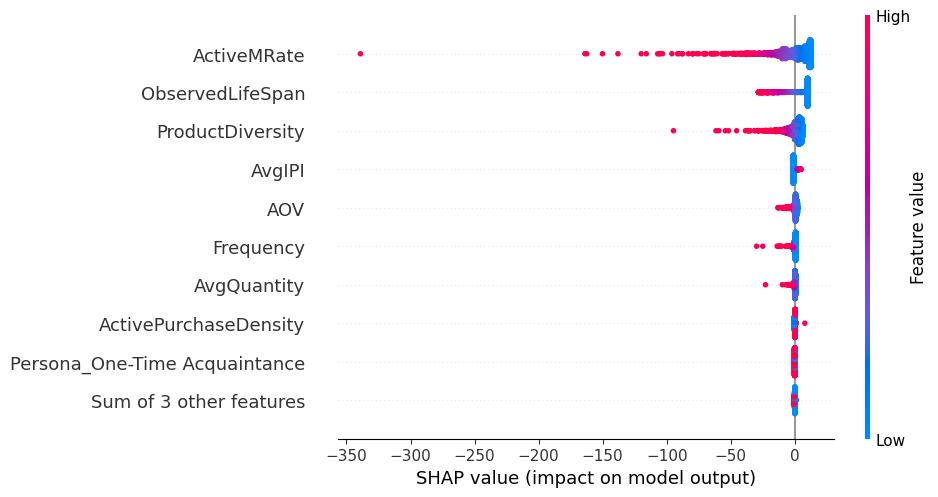

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import shap


X_train_clean = X_train.astype(float)

explainer = shap.LinearExplainer(model, X_train_clean)
shap_values = explainer(X_train_clean)

# Beeswarm plot
plt.clf()
shap.plots.beeswarm(shap_values, max_display=10)

As presented above the most important predictors of churn are `ActiveMRate`, `ObservedLifeSpan`, and `ProductDiversity`, respectively. Values in red present high features values, while those in blue are low features. That said, the high values of mentioned variables, seating on the left side of 0, are protective of churn, or rather reduce the probability of churn.

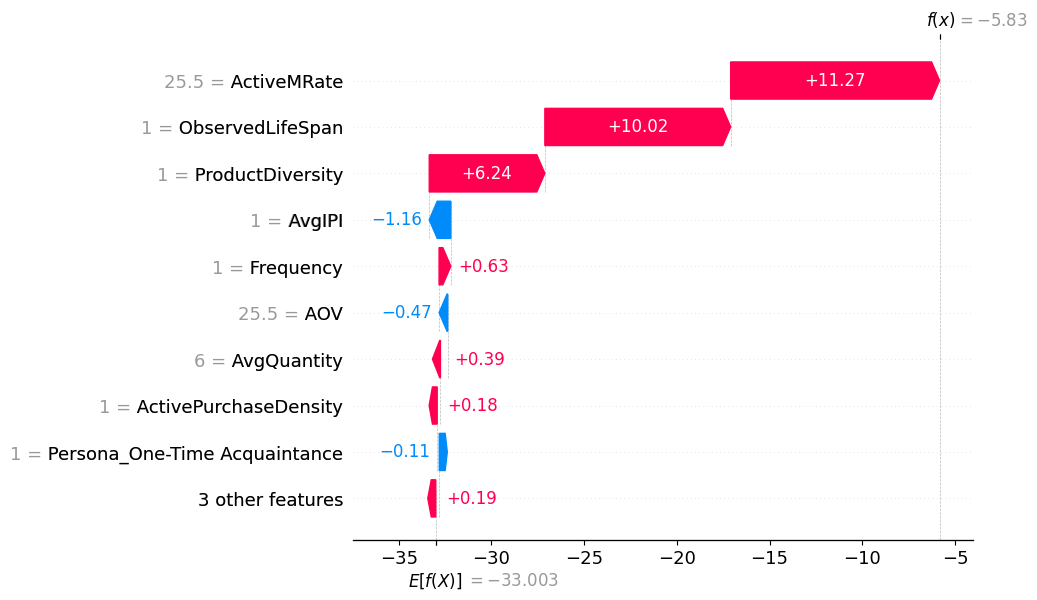

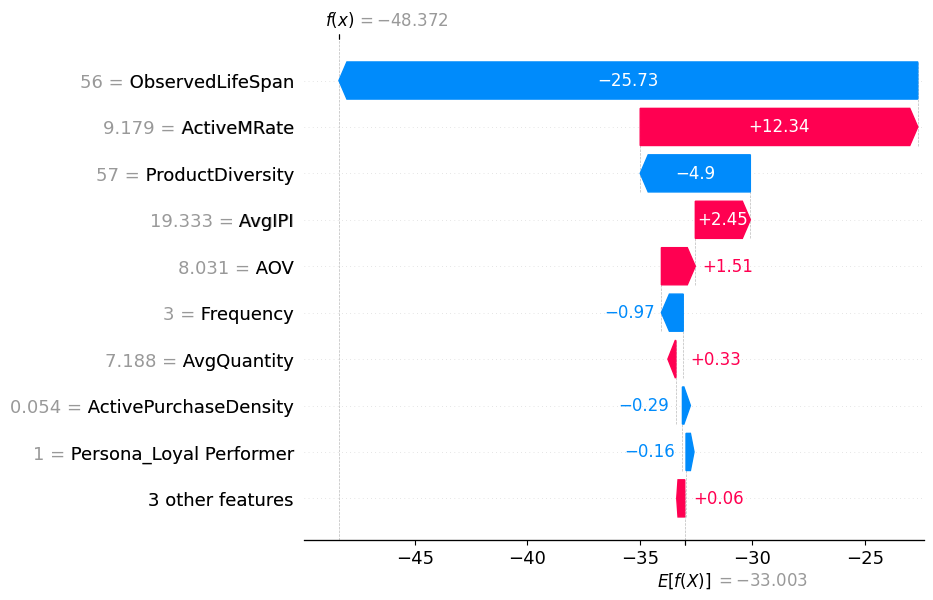

In [41]:
# Waterfall plot
plt.clf()
shap.plots.waterfall(shap_values[0], max_display=10)

plt.clf()
shap.plots.waterfall(shap_values[90], max_display=10)

Waterfall plots, showing how each feature contributes to pushing a prediction from the base model output, is displayed above. `-33.003` was the baseline score of any client, with red bars being the postive forces that push the score up, and blue bars being the negative scores that drag the score down.

- `Graph 1`: The low `ObservedLifeSpan` of 1, `ProductDiversity` of 1, and low ,`ActiveMRate` pushed the clients score up from `-33.00 to -5.83`, a `27.53` gain, suggests this client is high risk, and likely to churn.

- `Graph 2:` The clients high `ObservedLifeSpan` (56 days), alone dropped the predictive score by 25.73 points, coupled with a high `ProductDiversity`, dragged the clients score further into the negative, implying that they are safe and unlikely to churn.